<a href="https://colab.research.google.com/github/teguhsmlnna666/Teguh-Esa-Maulanna_2411532005_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
# load dataset
dataset_url = 'https://raw.githubusercontent.com/teguhsmlnna666/Teguh-Esa-Maulanna_2411532005_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=16)

In [15]:
logreg_unscaled = LogisticRegression(random_state=16, max_iter=10000)
logreg_unscaled.fit(X_train, y_train)
y_pred_unscaled = logreg_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
logreg_scaled = LogisticRegression(random_state=16)
logreg_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = logreg_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

In [25]:
print(f"Scaling vs Tanpa Scaling")
print(f"Akurasi TANPA Scaling: {acc_unscaled:.4f}")
print(f"Akurasi DENGAN Scaling: {acc_scaled:.4f}\n")

Scaling vs Tanpa Scaling
Akurasi TANPA Scaling: 0.9006
Akurasi DENGAN Scaling: 0.9415



In [19]:
y_pred_proba = logreg_scaled.predict_proba(X_test_scaled)[:, 1]

In [20]:
thresholds = [0.3, 0.5, 0.7]

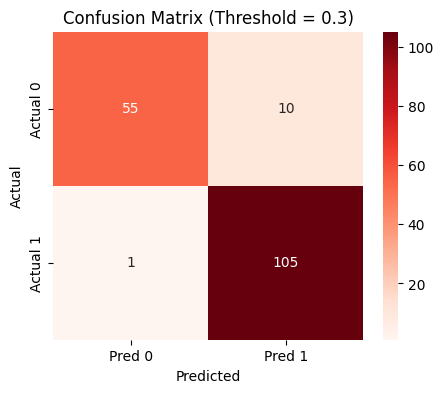


[ Threshold = 0.3 ]
              precision    recall  f1-score   support

           0       0.98      0.85      0.91        65
           1       0.91      0.99      0.95       106

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



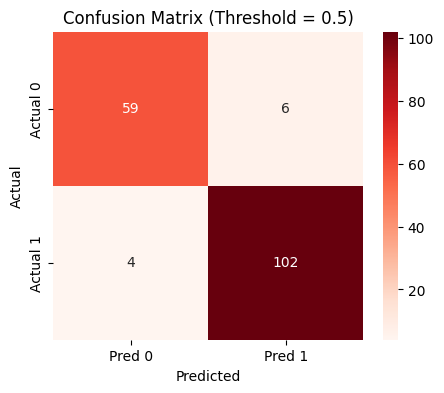


[ Threshold = 0.5 ]
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        65
           1       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



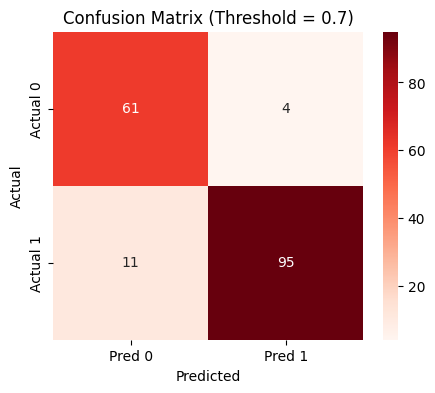


[ Threshold = 0.7 ]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        65
           1       0.96      0.90      0.93       106

    accuracy                           0.91       171
   macro avg       0.90      0.92      0.91       171
weighted avg       0.92      0.91      0.91       171



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

for thresh in thresholds:
    y_pred_custom = (y_pred_proba >= thresh).astype(int)

    cm = confusion_matrix(y_test, y_pred_custom)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['Actual 0','Actual 1'])

    plt.title(f'Confusion Matrix (Threshold = {thresh})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"\n[ Threshold = {thresh} ]")
    print(classification_report(y_test, y_pred_custom))
